# 08 - Traitement des Données Images

## Section : Gestion des Images

## Objectif
Préparer les images pour la modélisation en :
- Validant et filtrant les images (détection des fichiers corrompus)
- Définissant les paramètres de prétraitement (taille, normalisation)
- Construisant le dataset final image (chemins + labels)
- Sauvegardant les métadonnées pour les notebooks suivants

## Plan
1. Chargement des données (exploration 07)
2. Validation des images (détection des corrompues)
3. Paramètres de prétraitement (224×224, normalisation ImageNet)
4. Construction du dataset final
5. Sauvegarde et statistiques

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import sys
import warnings
warnings.filterwarnings('ignore')

sys.path.append(str(Path('../').resolve()))

from src.image import load_image_classification_data

ROOT = Path('../').resolve()
DATA_BRUT = ROOT / 'data brut'

IMAGE_DIR_RAW_TRAIN = DATA_BRUT / 'image_train'
IMAGE_DIR_RAW_BRUT = DATA_BRUT / 'image_brut'
IMAGE_DIR_PROCESSED_TRAIN = ROOT / 'data' / 'processed' / 'image_clean'
IMAGE_DIR_PROCESSED_CLEAN = ROOT / 'data' / 'processed' / 'image_clean'

IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

def list_image_files(image_dir: Path):
    if not image_dir.exists():
        return []
    return [p for p in image_dir.rglob('*') if p.is_file() and p.suffix.lower() in IMAGE_EXTS]

# Choix du dossier d'images
USE_ONLY_BRUT = True

if USE_ONLY_BRUT:
    IMAGE_DIR = IMAGE_DIR_RAW_BRUT
    IMAGE_SET = 'brut'
else:
    candidates = [
        IMAGE_DIR_RAW_TRAIN,
        IMAGE_DIR_RAW_BRUT,
        IMAGE_DIR_PROCESSED_TRAIN,
        IMAGE_DIR_PROCESSED_CLEAN,
    ]

    print("🔎 Recherche des images...")
    IMAGE_DIR = None
    for candidate in candidates:
        count = len(list_image_files(candidate))
        print(f"   - {candidate} : {count:,} fichiers")
        if count > 0 and IMAGE_DIR is None:
            IMAGE_DIR = candidate

    if IMAGE_DIR is None:
        IMAGE_DIR = IMAGE_DIR_RAW_BRUT

    if IMAGE_DIR in (IMAGE_DIR_RAW_TRAIN, IMAGE_DIR_PROCESSED_TRAIN, IMAGE_DIR_PROCESSED_CLEAN):
        IMAGE_SET = 'train'
    else:
        IMAGE_SET = 'brut'

OUTPUT_DIR = ROOT / 'data' / 'processed'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("✅ Configuration chargée")
print(f"📁 Images : {IMAGE_DIR}")
print(f"🧪 Set : {IMAGE_SET}")
if not list_image_files(IMAGE_DIR):
    print("⚠️ Aucun fichier image trouvé (.jpg/.jpeg/.png/.bmp/.webp). Vérifie image_train/image_brut.")

✅ Configuration chargée
📁 Images : C:\Users\pruvost_t\Desktop\Cours\Datascientest_projets\data brut\image_brut
🧪 Set : brut


## 1. Chargement et Construction du Dataset

In [2]:
if IMAGE_SET == 'train':
    print("📥 Chargement dataset train...")
    image_df = load_image_classification_data(DATA_BRUT, IMAGE_DIR, root=ROOT)
    print(f"✅ {len(image_df):,} paires (image, label) chargées")
else:
    print("📥 Chargement dataset brut...")
    image_files = list_image_files(IMAGE_DIR)
    print(f"   - Fichiers images détectés : {len(image_files):,}")
    image_data = []
    for f in image_files:
        try:
            parts = f.stem.split('_')
            if len(parts) >= 4 and parts[0].lower() == 'image' and parts[2].lower() == 'product':
                imageid = int(parts[1])
                productid = int(parts[3])
                try:
                    path_str = str(f.resolve().relative_to(ROOT))
                except ValueError:
                    path_str = str(f.resolve())
                image_data.append({
                    'imageid': imageid,
                    'productid': productid,
                    'image_path': path_str,
                })
        except (ValueError, IndexError):
            pass

    image_df = pd.DataFrame(image_data)
    image_df['prdtypecode'] = np.nan
    print(f"   - Noms d'images parsés : {len(image_df):,}")

    x_test_path = DATA_BRUT / 'X_test_update.csv'
    if x_test_path.exists():
        X_test = pd.read_csv(x_test_path, index_col=0)
        image_df = image_df.merge(X_test, on=['imageid', 'productid'], how='left')
        print(f"✅ {len(image_df):,} images brutes chargées (avec métadonnées si dispo)")
        missing_meta = image_df['designation'].isna().sum() if 'designation' in image_df.columns else 0
        if missing_meta > 0:
            print(f"   ⚠️ {missing_meta:,} images sans métadonnées dans X_test_update.csv")
    else:
        print(f"✅ {len(image_df):,} images brutes chargées (sans métadonnées)")

print(f"   Colonnes : {list(image_df.columns)}")
image_df.head()

📥 Chargement dataset brut...
   - Fichiers images détectés : 46,860
   - Noms d'images parsés : 46,860
✅ 46,860 images brutes chargées (avec métadonnées si dispo)
   ⚠️ 46,860 images sans métadonnées dans X_test_update.csv
   Colonnes : ['imageid', 'productid', 'image_path', 'prdtypecode', 'designation', 'description']


,imageid,productid,image_path,prdtypecode,designation,description
0,1142089742,884747735,data brut\image_brut\image_1142089742_product_...,NaN,NaN,NaN
1,1250268190,3831364140,data brut\image_brut\image_1250268190_product_...,NaN,NaN,NaN
2,1250268206,3831364148,data brut\image_brut\image_1250268206_product_...,NaN,NaN,NaN
3,1250268214,3831364212,data brut\image_brut\image_1250268214_product_...,NaN,NaN,NaN
4,1250268262,3831364233,data brut\image_brut\image_1250268262_product_...,NaN,NaN,NaN


## 2. Validation des Images (détection des corrompues)

In [3]:
from PIL import Image

def is_valid_image(path: str, base_dir: Path, min_size: tuple = (10, 10)) -> bool:
    try:
        full_path = base_dir / path if not Path(path).is_absolute() else Path(path)
        with Image.open(full_path) as img:
            img.verify()
        with Image.open(full_path) as img:
            if img.width < min_size[0] or img.height < min_size[1]:
                return False
        return True
    except Exception:
        return False

print("🔄 Validation des images...")
if len(image_df) == 0:
    print("   ⚠️ Aucune image à valider (dataset vide)")
else:
    print(f"   - À valider : {len(image_df):,}")
    valid_mask = [is_valid_image(p, ROOT) for p in image_df['image_path']]
    n_valid = sum(valid_mask)
    n_removed = len(image_df) - n_valid
    if n_removed > 0:
        image_df = image_df[valid_mask].copy()
        print(f"   ⚠️ {n_removed} images corrompues exclues")
    print(f"   ✅ {len(image_df):,} images valides")

if 'prdtypecode' in image_df.columns and image_df['prdtypecode'].notna().any():
    # Superclasse (24 classes) : Publications -> 9999
    CODE_SUPERCLASSE = 9999
    PUBLICATIONS_CLASSES = {10, 2280, 2403, 2705}
    image_df['prdtypecode_superclass'] = image_df['prdtypecode'].apply(
        lambda x: CODE_SUPERCLASSE if x in PUBLICATIONS_CLASSES else x
    )
    print(f"   ✅ Classes (27) : {image_df['prdtypecode'].nunique()}")
    print(f"   ✅ Classes (24) : {image_df['prdtypecode_superclass'].nunique()}")
else:
    print("   ⚠️ Pas de labels disponibles (dataset test)")

🔄 Validation des images...
   - À valider : 46,860
   ✅ 46,860 images valides
   ⚠️ Pas de labels disponibles (dataset test)


## 3. Paramètres de Prétraitement

In [4]:
PREPROCESS_CONFIG = {
    'target_size': (224, 224),
    'normalization': 'imagenet',
    'mean': [0.485, 0.456, 0.406],
    'std': [0.229, 0.224, 0.225],
}
print("📋 Paramètres de prétraitement (ResNet/ImageNet) :")
for k, v in PREPROCESS_CONFIG.items():
    print(f"   {k}: {v}")

📋 Paramètres de prétraitement (ResNet/ImageNet) :
   target_size: (224, 224)
   normalization: imagenet
   mean: [0.485, 0.456, 0.406]
   std: [0.229, 0.224, 0.225]


## 4. Sauvegarde du Dataset

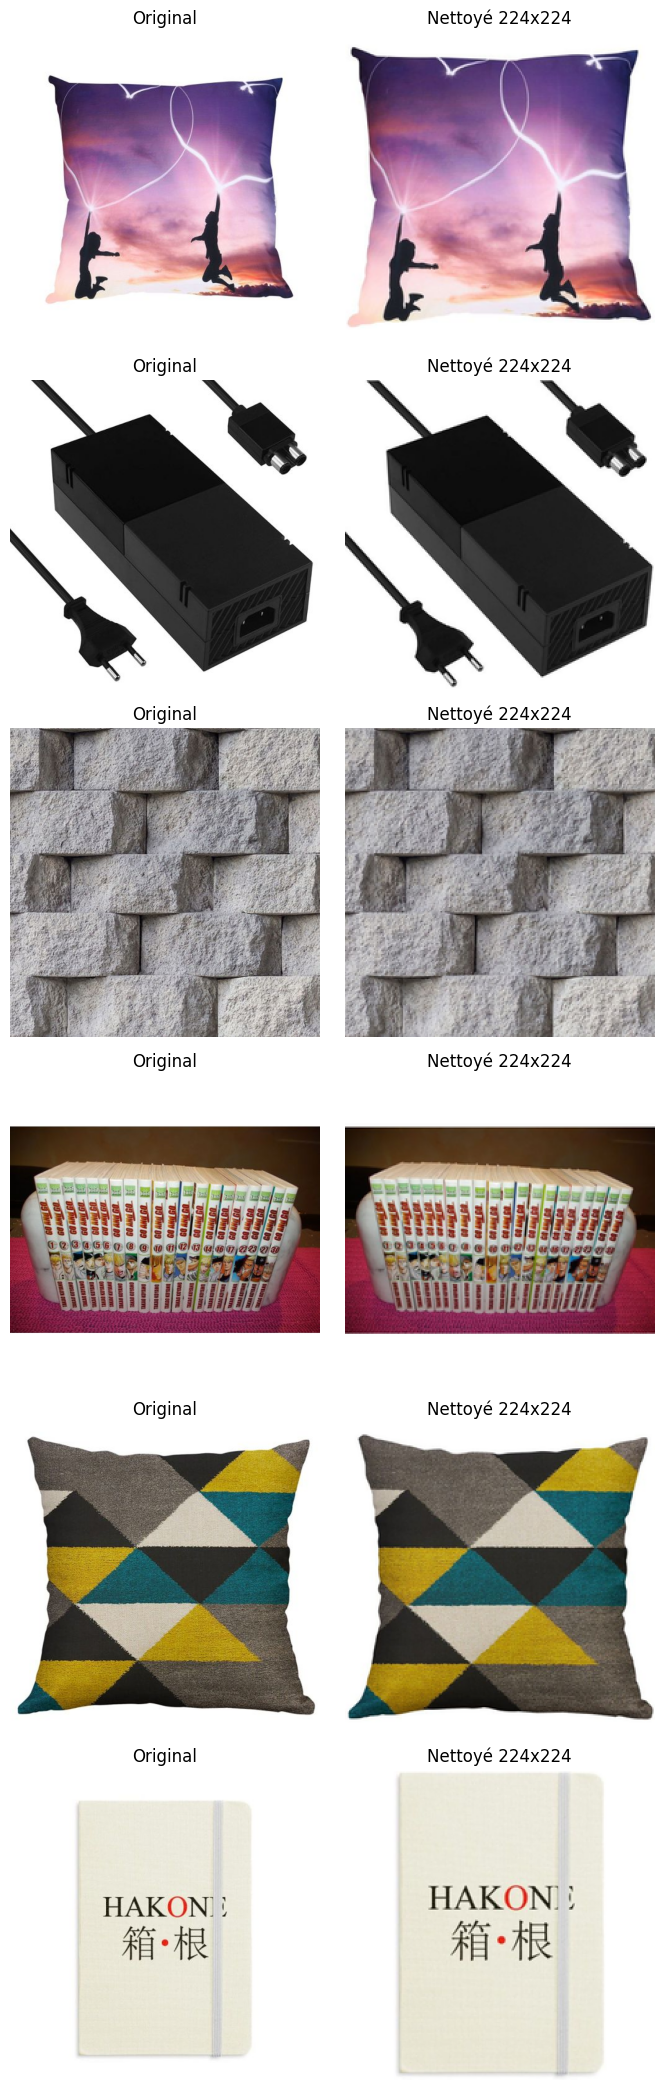

In [5]:
# Nettoyage visuel : suppression des bandes blanches + padding carré + resize
import matplotlib.pyplot as plt
from PIL import Image, ImageOps, ImageFilter

WHITE_THRESHOLD = 245
MIN_NONWHITE_PIXELS = 50
LOWRES_MIN_SIDE = 128


def trim_white_borders(img: Image.Image, threshold: int = WHITE_THRESHOLD, padding: int = 2) -> Image.Image:
    arr = np.asarray(img)
    if arr.ndim == 2:
        arr = np.stack([arr] * 3, axis=-1)
    non_white = np.any(arr < threshold, axis=-1)
    if not non_white.any():
        return img
    ys, xs = np.where(non_white)
    y0, x0 = ys.min(), xs.min()
    y1, x1 = ys.max() + 1, xs.max() + 1
    y0 = max(0, y0 - padding)
    x0 = max(0, x0 - padding)
    y1 = min(arr.shape[0], y1 + padding)
    x1 = min(arr.shape[1], x1 + padding)
    return img.crop((x0, y0, x1, y1))


def is_blank(img: Image.Image, threshold: int = WHITE_THRESHOLD, min_nonwhite: int = MIN_NONWHITE_PIXELS) -> bool:
    arr = np.asarray(img)
    if arr.ndim == 2:
        arr = np.stack([arr] * 3, axis=-1)
    non_white = np.any(arr < threshold, axis=-1)
    return int(non_white.sum()) < min_nonwhite


def pad_to_square(img: Image.Image, fill=(255, 255, 255)) -> Image.Image:
    w, h = img.size
    size = max(w, h)
    out = Image.new('RGB', (size, size), fill)
    out.paste(img, ((size - w) // 2, (size - h) // 2))
    return out


def enhance_lowres(img: Image.Image) -> Image.Image:
    img = ImageOps.autocontrast(img)
    img = img.filter(ImageFilter.UnsharpMask(radius=1.2, percent=150, threshold=3))
    return img


def preprocess_image(path: str, base_dir: Path, target_size=(224, 224)):
    full_path = base_dir / path if not Path(path).is_absolute() else Path(path)
    img = Image.open(full_path).convert('RGB')

    img = trim_white_borders(img)
    if is_blank(img):
        return None, {'blank': True, 'lowres': False}

    lowres = min(img.size) < LOWRES_MIN_SIDE
    if lowres:
        img = enhance_lowres(img)

    img = pad_to_square(img)
    img = img.resize(target_size, Image.LANCZOS)
    return img, {'blank': False, 'lowres': lowres}

# Apercu plus parlant : on évite les images quasi blanches
sample_paths = []
if len(image_df):
    candidates = image_df['image_path'].dropna().sample(n=min(40, len(image_df)), random_state=42)
    for p in candidates:
        try:
            full_path = ROOT / p if not Path(p).is_absolute() else Path(p)
            img = Image.open(full_path).convert('RGB')
            arr = np.asarray(img)
            if np.mean(arr) < 240:
                sample_paths.append(p)
            if len(sample_paths) >= 6:
                break
        except Exception:
            continue

if sample_paths:
    fig, axes = plt.subplots(len(sample_paths), 2, figsize=(7, 3.5 * len(sample_paths)))
    if len(sample_paths) == 1:
        axes = [axes]
    for i, p in enumerate(sample_paths):
        original = Image.open(ROOT / p if not Path(p).is_absolute() else p).convert('RGB')
        cleaned, flags = preprocess_image(p, ROOT, target_size=PREPROCESS_CONFIG['target_size'])
        axes[i][0].imshow(original)
        axes[i][0].set_title('Original')
        axes[i][0].axis('off')
        if cleaned is None:
            axes[i][1].text(0.5, 0.5, 'Image blanche\nexclue', ha='center', va='center')
            axes[i][1].set_title('Exclue')
            axes[i][1].axis('off')
        else:
            axes[i][1].imshow(cleaned)
            suffix = ' (lowres)' if flags.get('lowres') else ''
            axes[i][1].set_title(f'Nettoyé 224x224{suffix}')
            axes[i][1].axis('off')
    plt.tight_layout()
else:
    print("⚠️ Aucun sample valable pour l'aperçu")

In [6]:
# Application du nettoyage à tout le dataset
if len(image_df) == 0:
    print("⚠️ Dataset vide : rien à traiter")
else:
    import shutil

    cleaned_dir = OUTPUT_DIR / "image_clean"
    failed_dir = OUTPUT_DIR / "image_echec_clean"

    CLEAN_OUTPUTS = True
    if CLEAN_OUTPUTS:
        if cleaned_dir.exists():
            shutil.rmtree(cleaned_dir)
        if failed_dir.exists():
            shutil.rmtree(failed_dir)

    cleaned_dir.mkdir(parents=True, exist_ok=True)
    failed_dir.mkdir(parents=True, exist_ok=True)

    cleaned_paths = []
    failed = []
    blank_excluded = 0
    lowres_enhanced = 0

    print(f"🧹 Début nettoyage : {len(image_df):,} images")
    print(f"   - Sortie OK : {cleaned_dir}")
    print(f"   - Sortie échecs : {failed_dir}")
    print(f"   - Nettoyage des anciens résultats : {CLEAN_OUTPUTS}")

    for i, p in enumerate(image_df['image_path']):
        full_path = ROOT / p if not Path(p).is_absolute() else Path(p)
        try:
            img, flags = preprocess_image(p, ROOT, target_size=PREPROCESS_CONFIG['target_size'])
            if img is None:
                if flags.get('blank') and full_path.exists():
                    shutil.copy2(full_path, failed_dir / full_path.name)
                cleaned_paths.append(np.nan)
                failed.append(p)
                blank_excluded += 1
                continue
            if flags.get('lowres'):
                lowres_enhanced += 1
            out_path = cleaned_dir / Path(p).name
            img.save(out_path, format='JPEG', quality=95, optimize=True)
            try:
                rel_path = str(out_path.resolve().relative_to(ROOT))
            except ValueError:
                rel_path = str(out_path.resolve())
            cleaned_paths.append(rel_path)
        except Exception:
            if full_path.exists():
                shutil.copy2(full_path, failed_dir / full_path.name)
            cleaned_paths.append(np.nan)
            failed.append(p)

        if (i + 1) % 2000 == 0:
            print(f"   ... {i + 1:,} images traitées")

    image_df['image_path_clean'] = cleaned_paths
    print(f"✅ Images nettoyées : {len(image_df) - len(failed):,}")
    print(f"   - Low-res améliorées : {lowres_enhanced:,}")
    print(f"   - Blanches exclues : {blank_excluded:,}")
    if failed:
        print(f"   ⚠️ Exclues/échecs : {len(failed):,}")
        print("   (ex:)", failed[:5])
    print(f"📁 Dossier de sortie : {cleaned_dir}")

🧹 Début nettoyage : 46,860 images
   - Sortie OK : C:\Users\pruvost_t\Desktop\Cours\Datascientest_projets\data\processed\image_clean
   - Sortie échecs : C:\Users\pruvost_t\Desktop\Cours\Datascientest_projets\data\processed\image_echec_clean
   ... 2,000 images traitées
   ... 4,000 images traitées
   ... 6,000 images traitées
   ... 8,000 images traitées
   ... 10,000 images traitées
   ... 12,000 images traitées
   ... 14,000 images traitées
   ... 16,000 images traitées
   ... 18,000 images traitées
   ... 20,000 images traitées
   ... 22,000 images traitées
   ... 24,000 images traitées
   ... 26,000 images traitées
   ... 28,000 images traitées
   ... 30,000 images traitées
   ... 32,000 images traitées
   ... 34,000 images traitées
   ... 36,000 images traitées
   ... 38,000 images traitées
   ... 40,000 images traitées
   ... 42,000 images traitées
   ... 44,000 images traitées
   ... 46,000 images traitées
✅ Images nettoyées : 46,857
   - Low-res améliorées : 1,518
   - Blanche

In [7]:
output_path = OUTPUT_DIR / 'image_dataset_processed.csv'
image_df.to_csv(output_path, index=False)
print(f"✅ Dataset sauvegardé : {output_path}")
print(f"   - {len(image_df):,} lignes")

if 'prdtypecode' in image_df.columns and image_df['prdtypecode'].notna().any():
    print(f"   - 27 classes : {image_df['prdtypecode'].nunique()}")
    if 'prdtypecode_superclass' in image_df.columns:
        print(f"   - 24 classes : {image_df['prdtypecode_superclass'].nunique()}")
else:
    print("   - labels indisponibles (dataset test)")

print("\n✅ Prochaine étape : Notebook 09 - Modélisation baseline")

✅ Dataset sauvegardé : C:\Users\pruvost_t\Desktop\Cours\Datascientest_projets\data\processed\image_dataset_processed.csv
   - 46,860 lignes
   - labels indisponibles (dataset test)

✅ Prochaine étape : Notebook 09 - Modélisation baseline
